# ASL Recognition with CNNs

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will compare the performance of a Fully Connected Neural Network (FCNN) with that of a CNN on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [21]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [23]:
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except Exception:
    IN_COLAB = False

candidate_paths = [
    Path.cwd() / "data",
    Path.cwd().parent / "data",
    Path.cwd() / "data" / "asl_data",
    Path.cwd().parent / "data" / "asl_data",
]
data_base_path = next((path for path in candidate_paths if path.exists()), None)

### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [24]:
train_df = pd.read_csv(data_base_path / "train.csv")
val_df = pd.read_csv(data_base_path / "val.csv")
test_df = pd.read_csv(data_base_path / "test.csv")

In [25]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

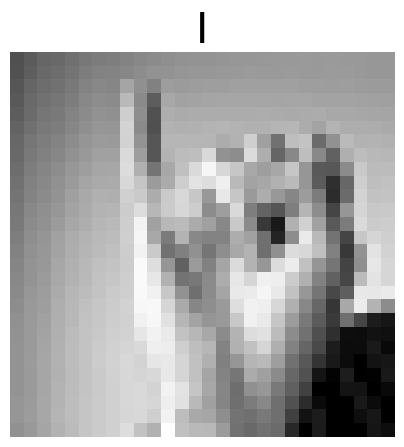

In [26]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [27]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [28]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [29]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well. 

In [30]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [31]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [32]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

In [33]:
def plot_learning_curves(histories):
    for model_name, history in histories.items():
        epochs = range(1, len(history['train_loss']) + 1)

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, history['train_loss'], label='Train loss')
        plt.plot(epochs, history['val_loss'], label='Validation loss')
        plt.title(f'{model_name} Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, history['train_acc'], label='Train accuracy')
        plt.plot(epochs, history['val_acc'], label='Validation accuracy')
        plt.title(f'{model_name} Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)
        plt.show()


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Training the models

### Baseline model - fully connected network

Before we implement the CNN, let's train a simple fully connected neural network (FCNN) as a baseline. This will help us understand the performance improvement that the CNN architecture provides for image data.

In [34]:
model_fcnn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512),
    nn.ReLU(),
    nn.Dropout(.3),

    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_fcnn = model_fcnn.to(device)

In [35]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_fcnn.parameters())

fcnn_res = train(model_fcnn, train_loader, val_loader, loss_function, optimizer, epochs)
fcnn_test_loss, fcnn_test_acc = test(model_fcnn, test_loader, loss_function)

print("FCNN test loss:", fcnn_test_loss)
print("FCNN test accuracy:", fcnn_test_acc)
print("FCNN trainable parameters:", count_trainable_parameters(model_fcnn))

Training:   0%|          | 0/20 [00:00<?, ?epoch/s]

Training: 100%|██████████| 20/20 [00:44<00:00,  2.25s/epoch, train_acc=0.8914, train_loss=0.3112, val_acc=0.7588, val_loss=0.8909]

FCNN test loss: 0.8586293086617337
FCNN test accuracy: 0.7593418851087553
FCNN trainable parameters: 676888


### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [37]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 28 x 28
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 14 x 14
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [38]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

print("CNN test loss:", cnn_test_loss)
print("CNN test accuracy:", cnn_test_acc)
print("CNN trainable parameters:", count_trainable_parameters(model_cnn))

Training: 100%|██████████| 20/20 [01:06<00:00,  3.33s/epoch, train_acc=0.9985, train_loss=0.0063, val_acc=0.9643, val_loss=0.1623]

CNN test loss: 0.16865400017129556
CNN test accuracy: 0.959007250418291
CNN trainable parameters: 403799


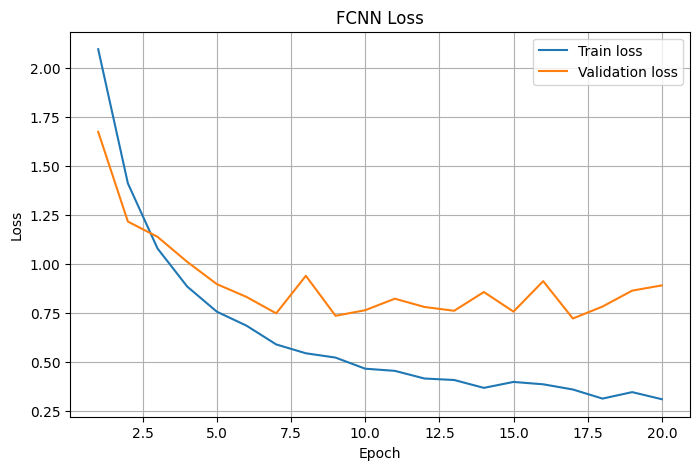

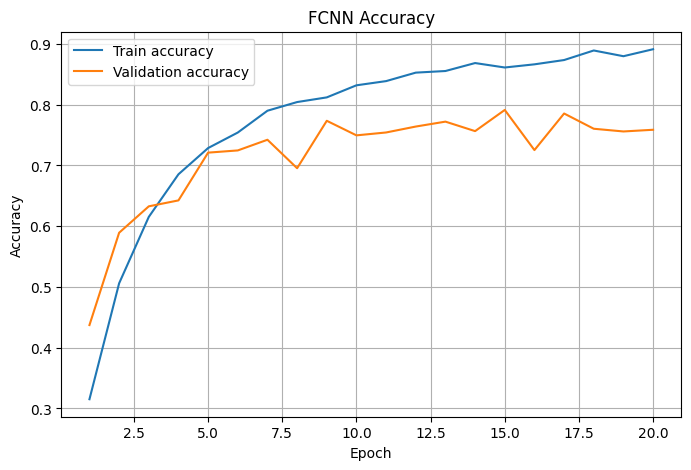

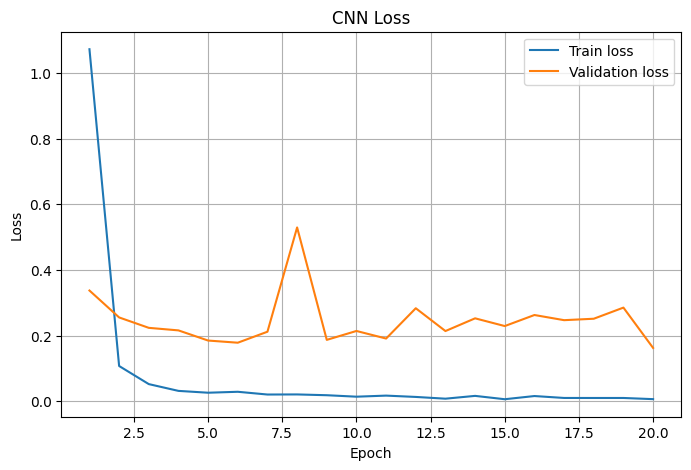

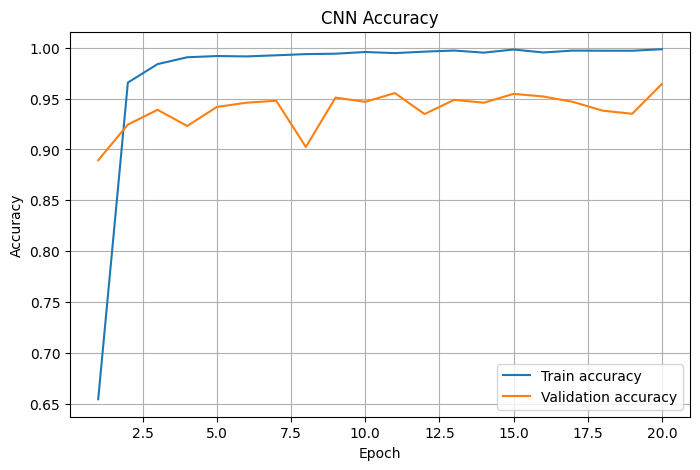

FCNN
Test loss: 0.8586293148781691
Test accuracy: 0.7593418851087553
Trainable parameters: 676888

CNN
Test loss: 0.16865400091713917
Test accuracy: 0.959007250418291
Trainable parameters: 403799


In [ ]:
plot_learning_curves({
    'FCNN': fcnn_res,
    'CNN': cnn_res
})

print("FCNN")
print("Test loss:", fcnn_test_loss)
print("Test accuracy:", fcnn_test_acc)
print("Trainable parameters:", count_trainable_parameters(model_fcnn))

print()

print("CNN")
print("Test loss:", cnn_test_loss)
print("Test accuracy:", cnn_test_acc)
print("Trainable parameters:", count_trainable_parameters(model_cnn))

## Reflection section

### Which model is better at classifying ASL images?

El CNN fue mejor obtuvo un test loss de 0.1687 y un accuaricy de 95.90% mientras que el FCNN fue de 0.85 y de 75.93%

### Which model was _faster_ to train?

FCCN tardo 45s 
CNN tardo 66s

### Plot and compare the learning curves of both models. What do you observe about their training and validation performance over epochs?

En el FCNN el entrenamiento sigue mejorando pero la validacion se estanca y empieza a varias, lo que signifcia que no generaliza bien. El CNN baja muy rapido y la presicion se mantiene mas estable, aprende y generaliza mejor.

### How many trainable parameters does each model have?

Remember that each convolutional layer has $K \times (C_{in} \times k_h \times k_w + 1)$ parameters, where $K$ is the number of filters, $C_{in}$ is the number of input channels, $k_h$ and $k_w$ are the kernel height and width, and the +1 accounts for the bias term.

Each fully connected layer has $N_{in} \times N_{out} + N_{out}$ parameters, where $N_{in}$ is the number of input features and $N_{out}$ is the number of output features.

FCNN:

Capa 1: (28 * 28) * 512 + 512 = 401920  
Capa 2: 512 * 512 + 512       = 262656  
Capa 3: 512 * 24 + 24         = 12312  
Total                         = 676888   

CNN:

Capa 1: 25 * (1 * 3 * 3 + 1)       = 250  
Capa 2: 50 * (25 * 3 * 3 + 1)      = 11300  
Capa 3: 75 * (50 * 3 * 3 + 1)      = 33825  
Capa 4: (75 * 3 * 3) * 512 + 512   = 346112  
Capa 5: 512 * 24 + 24              = 12312  
Total                             = 403799    

FCNN = 676888
CNN  = 403799

### How do the models compare in terms of overfitting? Why do you think that is the case?

Los dos modelos tienen overfitting pero el FCNN tiene mucho mas, posiblemente porque el CNN esta especializado para trabajar con imagenes por eso tiene mejores resultados

### Final conclusions and remarks

El CNN fue el mejor modelo, entonces en un problema donde se trabaje con imagenes conviene utilizar el CNN